# Seaborn

Librería de Python pensada para la visualización de datos, normalmente estadísticos. Está construida sobre Matploty y se integra de forma nativa con Pandas. Tiene gráficas más complejas y visuales que su hermana pequeña Matploty. 

Se usa mucho en los análisis exploratorios de datos (EDA), en proyectos de ciencia de datos. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
datos = {
    "Trimestre": ["T1", "T2", "T3", "T4", "T1", "T2", "T3", "T4"],
    "Ventas_USD": [15000, 18000, 22000, 25000, 12000, 14000, 19000, 21000],
    "Sucursal": ["Norte", "Norte", "Norte", "Norte", "Sur", "Sur", "Sur", "Sur"]
}

df = pd.DataFrame(datos)

## 1. Gráfico de Líneas Categorizado (sns.lineplot)

**Casos de uso**: Comparar la evolución de una variable a lo largo del tiempo, pero separada por categorías.
**Data Model**: Tabla (Data Frame) con columnas: tiempo, valor numérico y categoría para poder hacer una agrupación. 

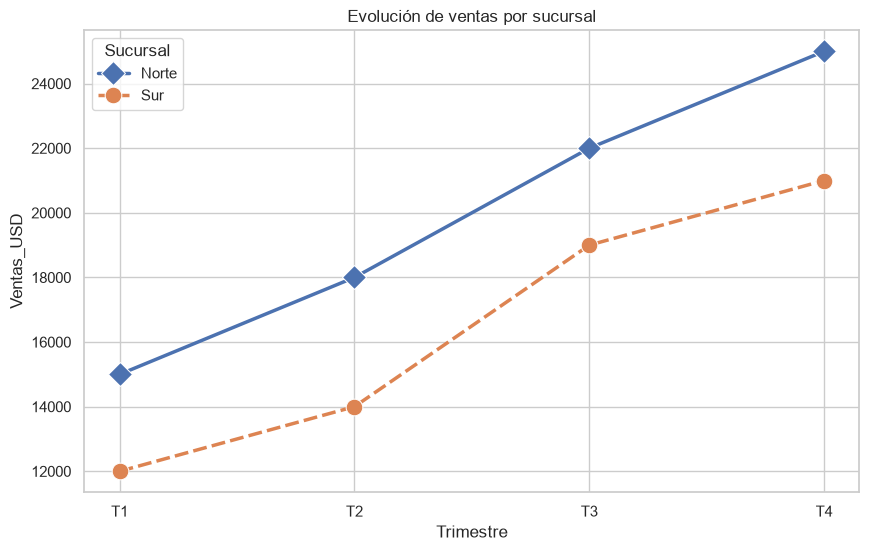

In [3]:
sns.set_theme(style= 'whitegrid') # color del fondo del gráfico
plt.figure(figsize=(10,6))
plt.title('Evolución de ventas por sucursal')

sns.lineplot(
    data=df, 
    x='Trimestre', 
    y='Ventas_USD', 
    hue='Sucursal',
    style='Sucursal', #si queremos usar marcas distintas para cada línea 
    markers={'Norte': 'D', 'Sur':'o'},
    markersize= 12,
    linewidth=2.5 )

plt.xlabel = 'Trimestre'
plt.ylabel = 'Ventas'
plt.show()
  

plt.show()

## 2. Gráfico de Barras Agrupado (sns.barplot)

**Casos de uso**: Compara valores promedio (valores agregados) de diferentes categorías divididas en subgrupos.
        
**Data Model**: Eje x, categorías primarias, las que queremos evaluar. Eje y, valores numéricos que queremos comparar. Hue, subcategorías

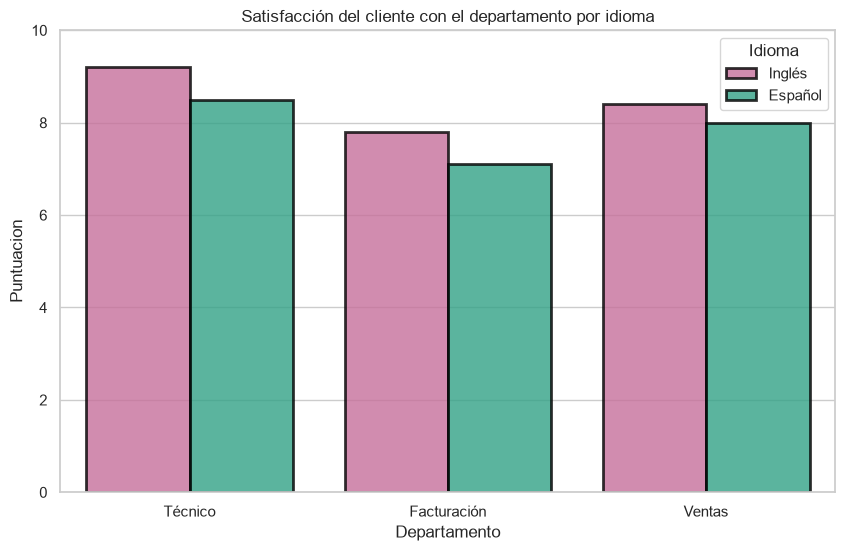

In [4]:
datos_soporte = {
    "Departamento": ["Técnico", "Técnico", "Facturación", "Facturación", "Ventas", "Ventas"],
    "Puntuacion": [8.5, 9.2, 7.1, 7.8, 8.0, 8.4],
    "Idioma": ["Español", "Inglés", "Español", "Inglés", "Español", "Inglés"]
}

df_soporte = pd.DataFrame(datos_soporte)


plt.figure(figsize=(10,6))
plt.title('Satisfacción del cliente con el departamento por idioma')
#este gráfico tiene la posibilidad de ponerle una escala
plt.ylim(0,10) #escala de 0 a 10
sns.barplot(data=df_soporte, x='Departamento', y='Puntuacion', hue='Idioma', edgecolor='black', linewidth=2,alpha=0.8, 
            hue_order=['Inglés', 'Español'], dodge=True,  palette=["#D4629B", "#1fb58f"]) 
#con dodge = False se superponen las barras del idioma para cada departamento
plt.show()

## 3. Gráfico de dispersión relacional (sns.scatterplot)

**Casos de uso**: Visualizar relaciones entre dos variables cuantitativas y agregar dimensiones adicionales.
   
**Data Model**: Coordenadas x e y numéricas

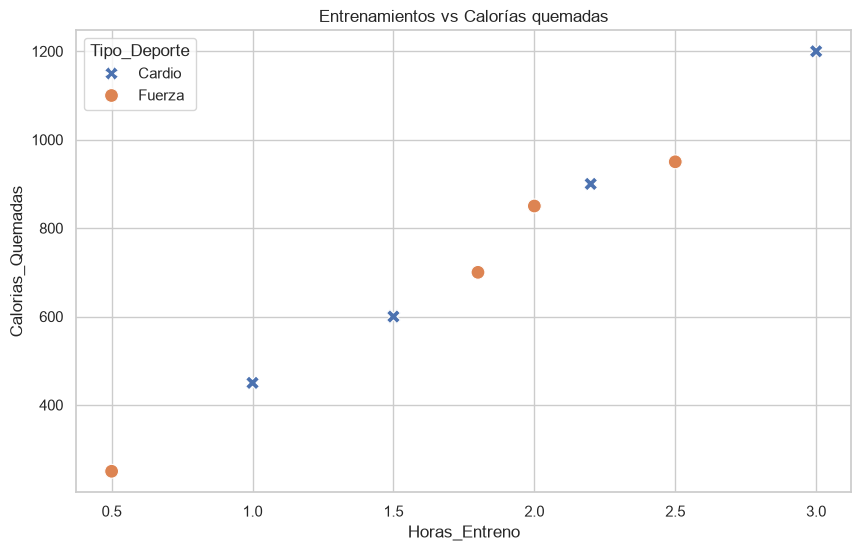

In [5]:
datos_deporte = {
    "Horas_Entreno": [1.5, 2.0, 1.0, 3.0, 2.5, 0.5, 2.2, 1.8],
    "Calorias_Quemadas": [600, 850, 450, 1200, 950, 250, 900, 700],
    "Tipo_Deporte": ["Cardio", "Fuerza", "Cardio", "Cardio", "Fuerza", "Fuerza", "Cardio", "Fuerza"]
}

df_deporte = pd.DataFrame(datos_deporte)

plt.figure(figsize=(10,6))
plt.title('Entrenamientos vs Calorías quemadas')
sns.scatterplot(data=df_deporte, x= 'Horas_Entreno', y='Calorias_Quemadas', hue='Tipo_Deporte', s=100, style='Tipo_Deporte', markers=['X', 'o'])
plt.show()



## 4. Histograma con Densidad (sns.histplot)

**Casos de uso**: Mostrar distribución de datos con una curva que suavize dicha distribución (KDE) que facilita ver los picos y la concentración (todo lo que quede por debajo de la curva)
   
**Data Model**: Un único listado numéricos, ya que medimos repetición y concentración. 

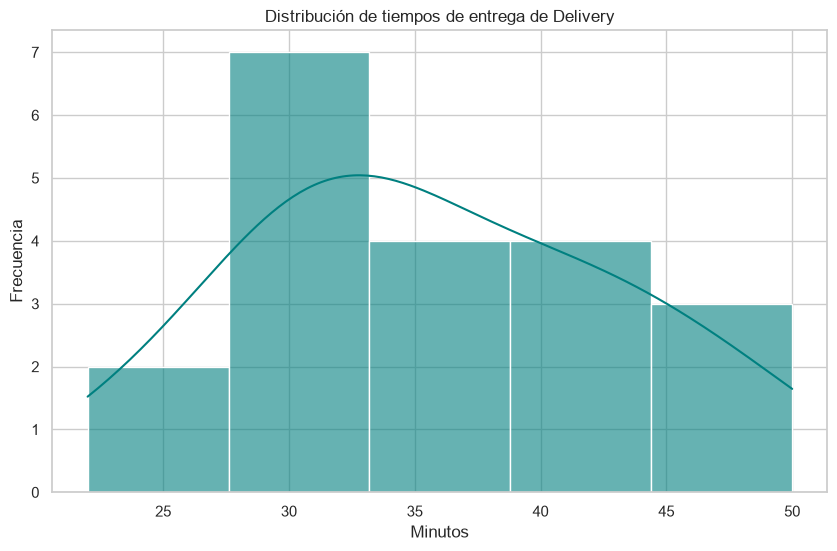

In [6]:
# Dataset: Tiempos de entrega de comida a domicilio (en minutos)
tiempos = [22, 25, 28, 30, 31, 32, 33, 35, 38, 40, 41, 42, 45, 48, 50, 29, 31, 35, 36, 44]

df_tiempos = pd.DataFrame({'Tiempo_minutos': tiempos})
plt.figure(figsize=(10,6))
plt.title('Distribución de tiempos de entrega de Delivery')
hist = sns.histplot(data=df_tiempos, x='Tiempo_minutos', color='teal', alpha=0.6, bins=5, edgecolor='white', kde=True) 
#bins = raíz cuadrada del número total de la muestra, redondeando hacia arriba. O también vale bins=auto
#kde True saca la línea
hist.set_xlabel('Minutos')
hist.set_ylabel('Frecuencia')
plt.show()


## 5. Diagrama de caja (sns.boxplot)

**Casos de uso**: Visualización de distribuciones estadísticas (mediana, outliers, rango intercuartílico) comparando múltiples grupos.
   
**Data Model**: Columna en eje x que sea la categorización, columna numérica en el eje y

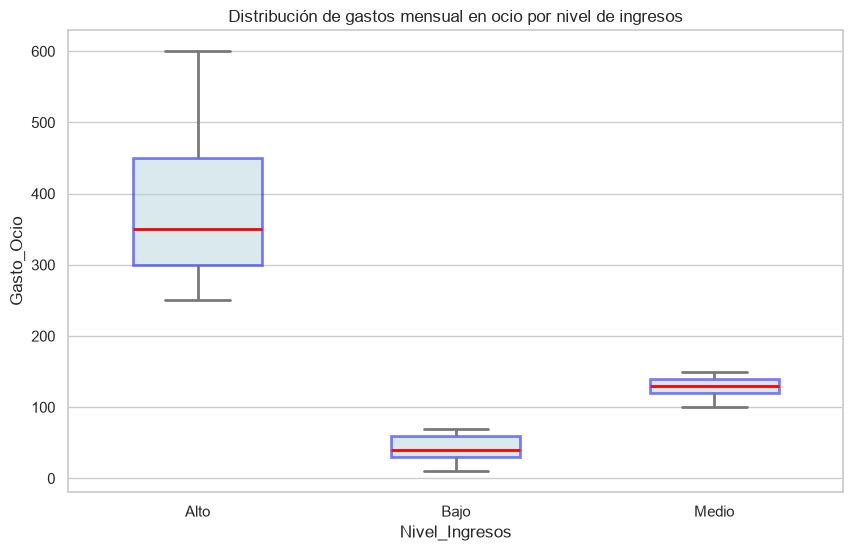

In [7]:
# Dataset: Gasto mensual en ocio agrupado por nivel de ingresos del usuario
datos_ocio = {
    "Nivel_Ingresos": ["Bajo"]*5 + ["Medio"]*5 + ["Alto"]*5,
    "Gasto_Ocio": [
        10, 60, 40, 70, 30,          # Ingreso Bajo
        120, 150, 100, 130, 140,     # Ingreso Medio
        300, 450, 250, 350, 600
                    # Ingreso Alto (600 es un valor atípico alto)
    ]
}
df_ocio = pd.DataFrame(datos_ocio)

plt.figure(figsize=(10,6))
plt.title('Distribución de gastos mensual en ocio por nivel de ingresos')
sns.boxplot(data=df_ocio, x='Nivel_Ingresos', y='Gasto_Ocio', order=['Alto', 'Bajo', 'Medio'], width=0.5, linewidth= 2, medianprops={'color':'red', 'linewidth':2}, color='lightblue', boxprops={'alpha':0.5, 'edgecolor':'blue'})
#width es el ancho de la caja, linewidth el grosor del borde 
#plt.ylabel('Gasto en €')
plt.show()

## 6. Diagrama de violín (sns.violinplot)
  
**Casos de uso**: Similar al anterior, pero permite ver cada dato de forma independiente, además de la dispersión. Si es alargado, hay más dispersión. 
  
**Data Model**: Eje x categoría (valor cualitativo), eje y un valor numérico

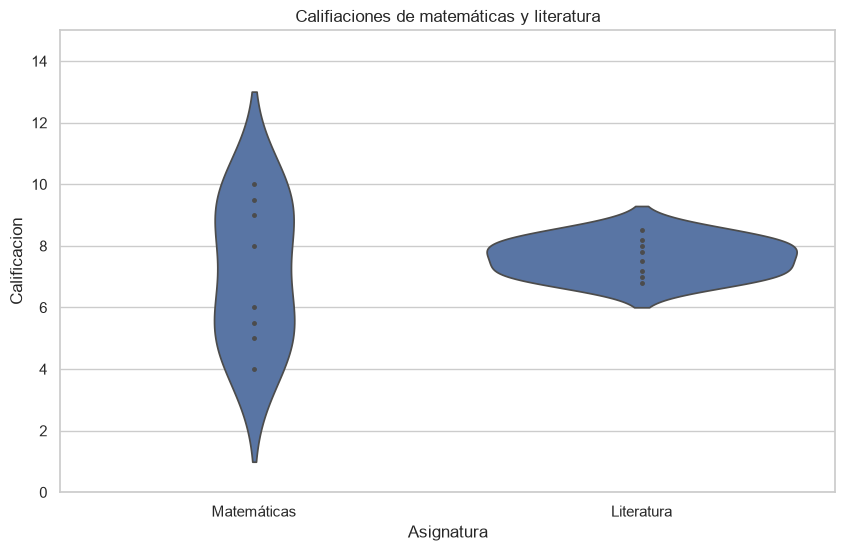

In [8]:
datos_clase = {
    "Asignatura": ["Matemáticas"]*8 + ["Literatura"]*8,
    "Calificacion": [
        4, 5, 5.5, 6, 8, 9, 9.5, 10,       # Matemáticas (distribución dispersa)
        7, 7.5, 7.2, 8, 8.2, 7.8, 6.8, 8.5  # Literatura (muy concentrada alrededor de 7.5-8)
    ]
}

df_clase = pd.DataFrame(datos_clase)

plt.figure(figsize=(10,6))
plt.title('Califiaciones de matemáticas y literatura')
plt.ylim(0,15) #límite de 11 en el lienzo sobre el eje x para que el gráfico no quede muy pegado 
sns.violinplot(data=df_clase, x="Asignatura", y="Calificacion", inner='point')
# inner 'box' (caja por defecto), 'quartile' (líneas de cuartiles), 'point' (puntos exactos), 'stick' (palitos)
plt.show()


## 7. Mapa de calor (sns.heatmap)
   
**Casos de uso**: Visualizar matrices numéricas (multidata) asignando variaciones de color según la intensidad del valor
   
**Data Model**: Matriz cuadrada

                 Horas_Sueno  Minutos_Deporte  Cafes_Dia
Horas_Sueno         1.000000        -0.545239  -1.000000
Minutos_Deporte    -0.545239         1.000000   0.545239
Cafes_Dia          -1.000000         0.545239   1.000000


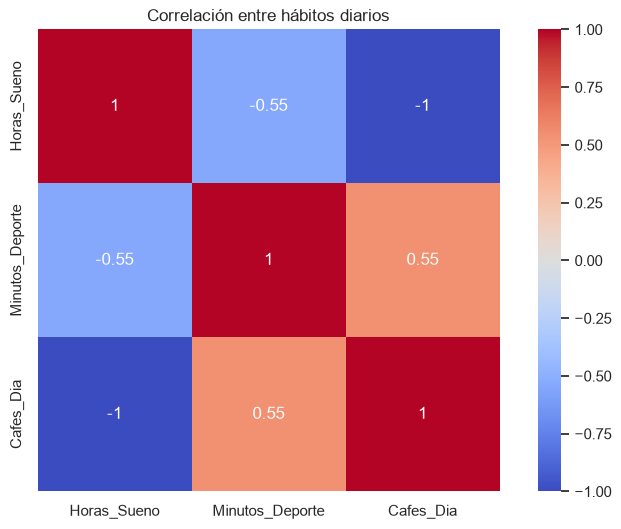

In [9]:
habits = {
    "Horas_Sueno": [8, 7, 6, 8, 5, 7, 6, 9, 5, 8],
    "Minutos_Deporte": [45, 30, 60, 0, 15, 45, 20, 10, 90, 0],
    "Cafes_Dia": [1, 2, 3, 1, 4, 2, 3, 0, 4, 1]
}

df_habitos = pd.DataFrame(habits)

# Matriz de correlación lineal: Es una tabla que cruza todas las columnas numéricas para medir cómo se relacionan entre sí matemáticamente. 

# Coeficiente de Pearson (r) para cada par de vbles. Este valor siempre va entre -1 y 1
    # Cerca del 1 (correlacion lineal positiva): Si una variable sube la otra tambien (Altura y peso)

    # Cerca de -1 (correlación lineal negativa): Si una variables suba la otra baja (Velocidad y duración de viaje)
    
    # Cerca de 0 (sin correlación): No hay ninguna relación lineal entre esas dos variables. Los puntos parecen nube desordenada

matriz_correlacion = df_habitos.corr()
print(matriz_correlacion)


plt.figure(figsize=(10,6))
plt.title('Correlación entre hábitos diarios')
sns.heatmap(data=matriz_correlacion, cmap='coolwarm', annot=True, square=True)
#otros cmap: Spectral, vlag
#annot para que aparezca el coef de Pearson dentro de cada cuadrado
#square para que los cuadrados sean perfectos
plt.show()